In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from sklearn.datasets import load_iris, load_breast_cancer

data = load_iris(as_frame=True)
df = data.frame
df
# data = load_breast_cancer(as_frame=True)
# df = data.frame
# df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
# mean columns only
df_clean = df.filter(regex='mean')
df_clean

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883
...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016


In [ ]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


In [ ]:
df.corr().style.applymap(lambda x: 'color : red' if x > 0.85 else '')

<ipython-input-9-74f4868a9bda>:1: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df.corr().style.applymap(lambda x: 'color : red' if x > 0.85 else '')


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


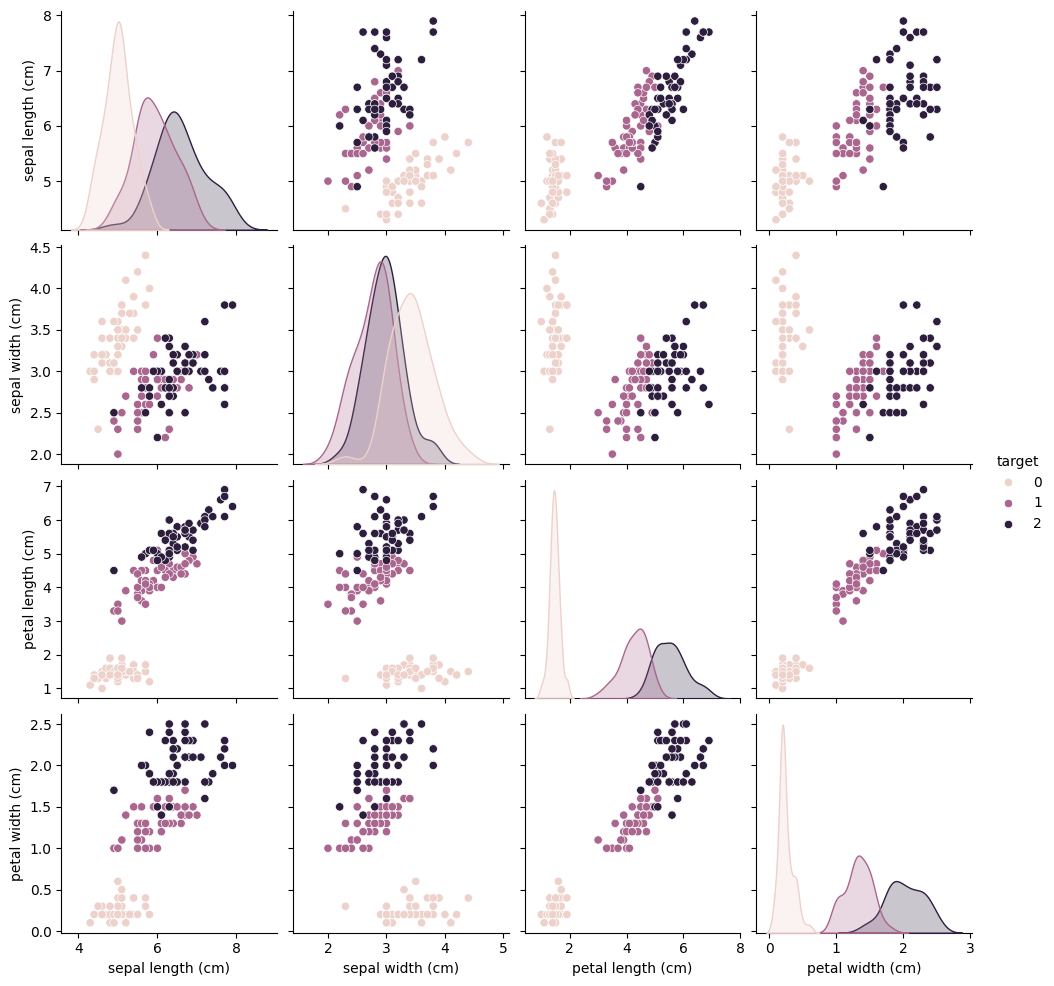

In [ ]:
# prompt: pairplot

import seaborn as sns
sns.pairplot(df, hue='target')
plt.show()


In [ ]:
df_clean = df_clean.drop(columns=['mean perimeter', 'mean area', 'mean compactness', 'mean concave points'])
df_clean

,mean radius,mean texture,mean smoothness,mean concavity,mean symmetry,mean fractal dimension
0,17.99,10.38,0.11840,0.30010,0.2419,0.07871
1,20.57,17.77,0.08474,0.08690,0.1812,0.05667
2,19.69,21.25,0.10960,0.19740,0.2069,0.05999
3,11.42,20.38,0.14250,0.24140,0.2597,0.09744
4,20.29,14.34,0.10030,0.19800,0.1809,0.05883
...,...,...,...,...,...,...
564,21.56,22.39,0.11100,0.24390,0.1726,0.05623
565,20.13,28.25,0.09780,0.14400,0.1752,0.05533
566,16.60,28.08,0.08455,0.09251,0.1590,0.05648
567,20.60,29.33,0.11780,0.35140,0.2397,0.07016


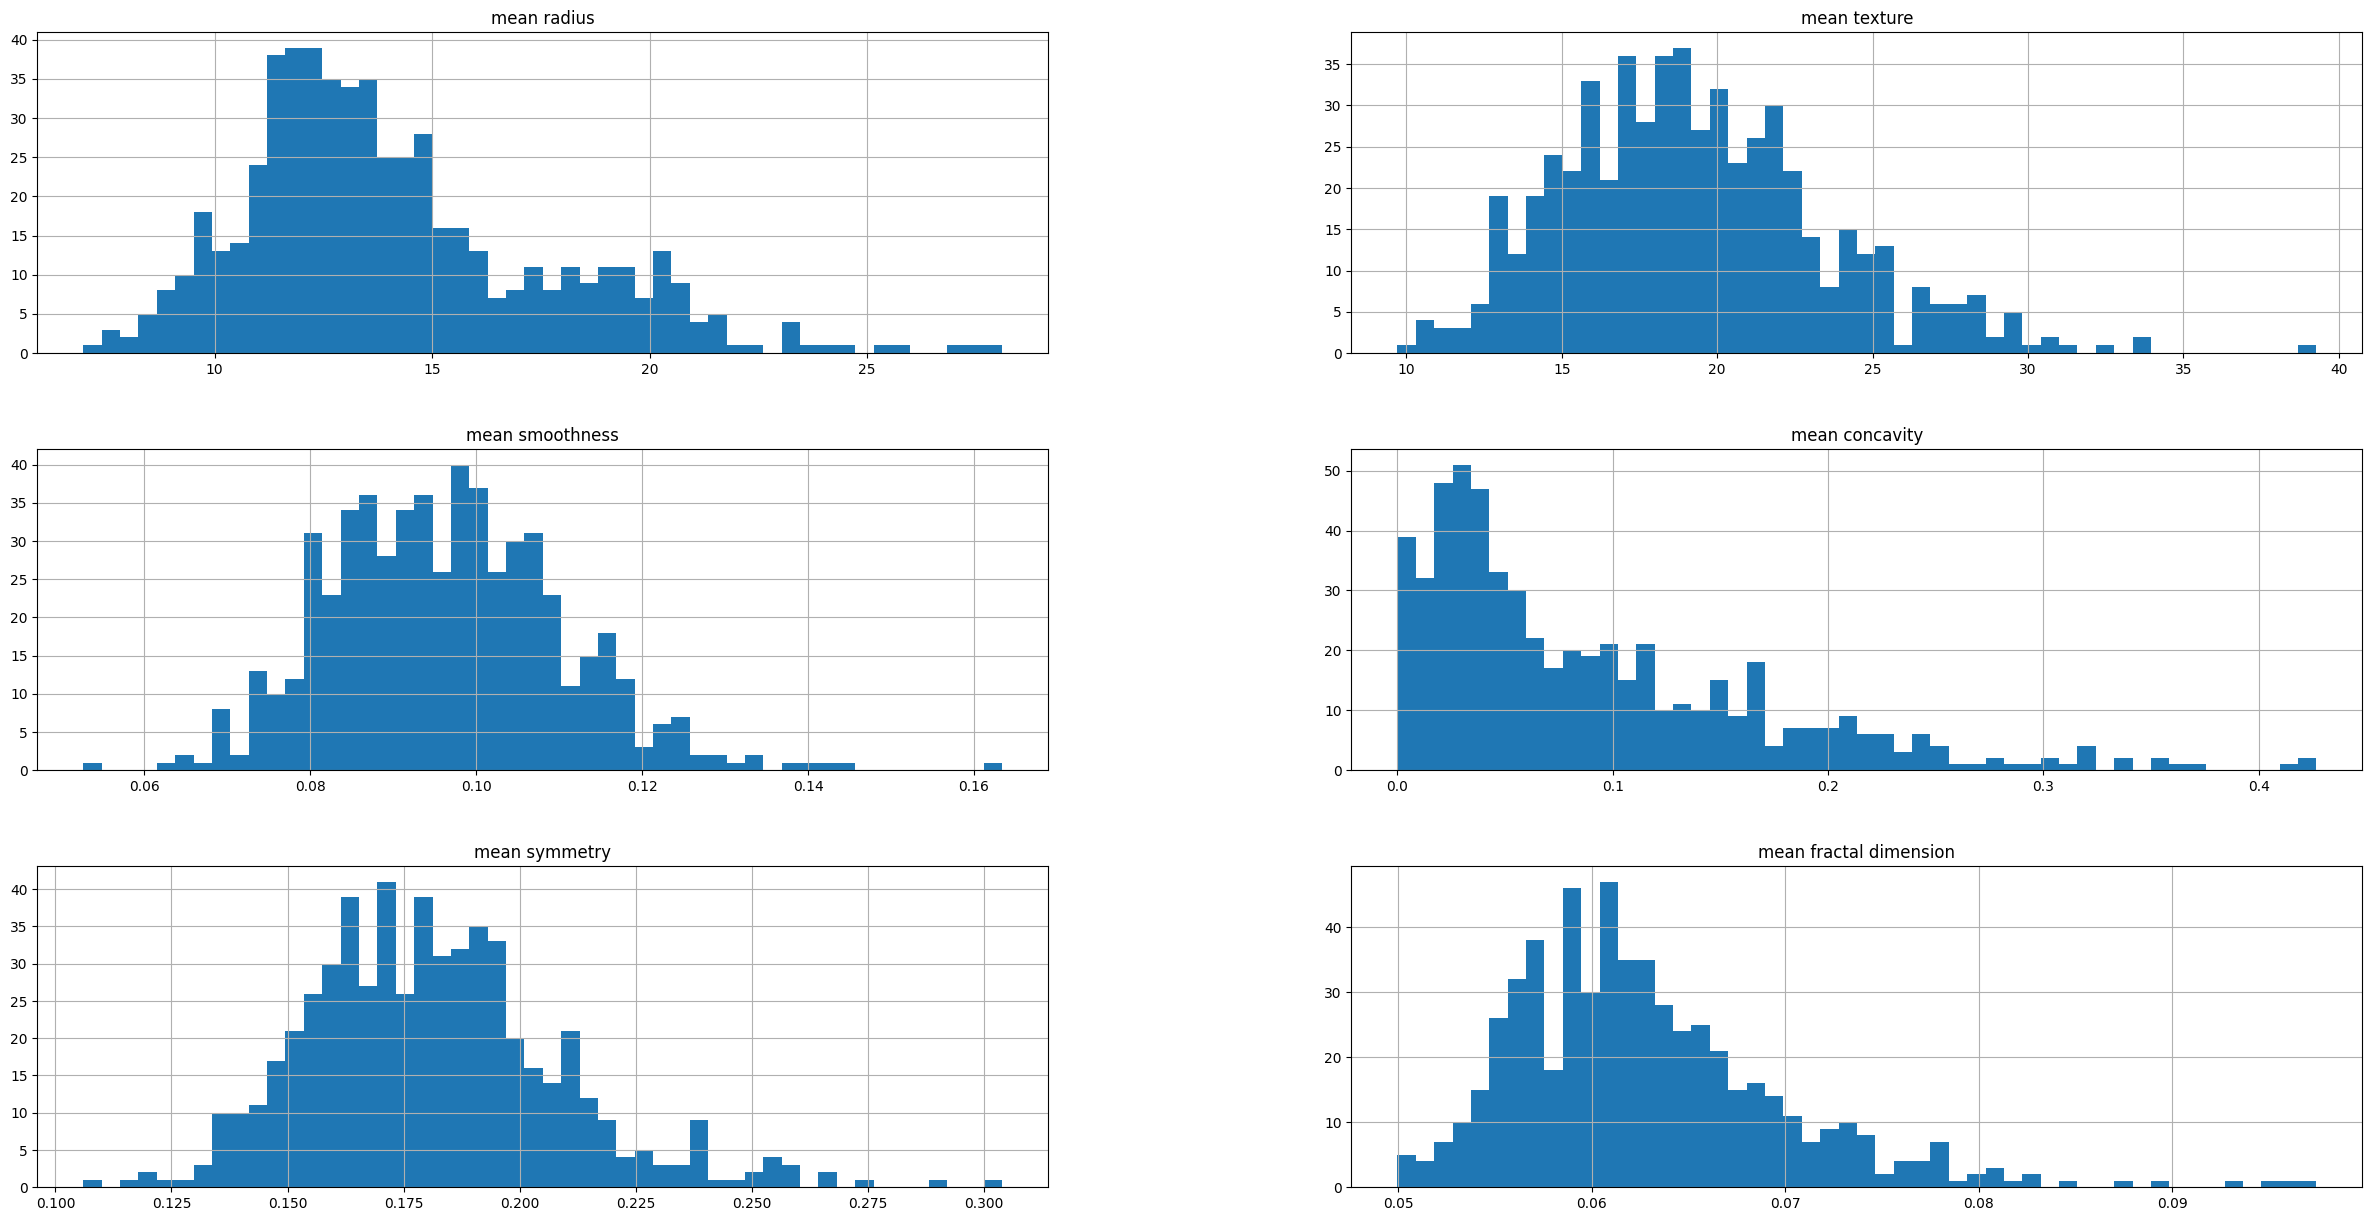

In [ ]:
# Check for outliers
df_clean.hist(bins=50, figsize=(30,15));

In [ ]:
df_clean['target'] = data.target
df_clean

,mean radius,mean texture,mean smoothness,mean concavity,mean symmetry,mean fractal dimension,target
0,17.99,10.38,0.11840,0.30010,0.2419,0.07871,0
1,20.57,17.77,0.08474,0.08690,0.1812,0.05667,0
2,19.69,21.25,0.10960,0.19740,0.2069,0.05999,0
3,11.42,20.38,0.14250,0.24140,0.2597,0.09744,0
4,20.29,14.34,0.10030,0.19800,0.1809,0.05883,0
...,...,...,...,...,...,...,...
564,21.56,22.39,0.11100,0.24390,0.1726,0.05623,0
565,20.13,28.25,0.09780,0.14400,0.1752,0.05533,0
566,16.60,28.08,0.08455,0.09251,0.1590,0.05648,0
567,20.60,29.33,0.11780,0.35140,0.2397,0.07016,0


In [ ]:
# prompt: from df_clean remove rows where mean_radius>25, or mean_texture>35, or mean_smoothness>0.15

# Remove rows based on specified conditions
df_clean = df_clean[~((df_clean['mean radius'] > 25) | (df_clean['mean texture'] > 35) | (df_clean['mean smoothness'] > 0.15))]
df_clean


,mean radius,mean texture,mean smoothness,mean concavity,mean symmetry,mean fractal dimension,target
0,17.99,10.38,0.11840,0.30010,0.2419,0.07871,0
1,20.57,17.77,0.08474,0.08690,0.1812,0.05667,0
2,19.69,21.25,0.10960,0.19740,0.2069,0.05999,0
3,11.42,20.38,0.14250,0.24140,0.2597,0.09744,0
4,20.29,14.34,0.10030,0.19800,0.1809,0.05883,0
...,...,...,...,...,...,...,...
564,21.56,22.39,0.11100,0.24390,0.1726,0.05623,0
565,20.13,28.25,0.09780,0.14400,0.1752,0.05533,0
566,16.60,28.08,0.08455,0.09251,0.1590,0.05648,0
567,20.60,29.33,0.11780,0.35140,0.2397,0.07016,0


In [ ]:
# Feature scaling
X = {
'weight':[1200, 800, 200, 900, 1200, 1500],
'height':[2,4,7,4,3,6]
 }

In [ ]:
# prompt: normalize X

from sklearn.preprocessing import MinMaxScaler

X = pd.DataFrame(X)

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized, columns = X.columns)

X_normalized


,weight,height
0,0.769231,0.0
1,0.461538,0.4
2,0.000000,1.0
3,0.538462,0.4
4,0.769231,0.2
5,1.000000,0.8


In [ ]:
# One-hot encoding
X = {
      'Colors': ['green', 'red', 'red', 'red', 'yellow', 'yellow', 'purple', 'red', 'blue', 'red', 'purple', 'red', 'yellow', 'yellow', 'blue', 'yellow', 'blue', 'green', 'red', 'red', 'purple', 'purple', 'green', 'green', 'red', 'blue', 'green', 'red', 'green', 'purple', 'red', 'purple', 'purple', 'blue', 'purple', 'red', 'red', 'red', 'yellow', 'blue', 'green', 'green', 'purple', 'purple', 'yellow', 'red', 'red', 'yellow', 'purple', 'green']
    }

In [ ]:
# prompt: converte X to a dataframe

X = pd.DataFrame(X)
X

,Colors
0,green
1,red
2,red
3,red
4,yellow
5,yellow
6,purple
7,red
8,blue
9,red


In [ ]:
# Method 1: pandas get_dummies
X = pd.get_dummies(X, columns = ['Colors'])
X

,Colors_blue,Colors_green,Colors_purple,Colors_red,Colors_yellow
0,False,True,False,False,False
1,False,False,False,True,False
2,False,False,False,True,False
3,False,False,False,True,False
4,False,False,False,False,True
5,False,False,False,False,True
6,False,False,True,False,False
7,False,False,False,True,False
8,True,False,False,False,False
9,False,False,False,True,False


In [ ]:
# Method 2: One-hot encoder using sklearn

from sklearn.preprocessing import OneHotEncoder

X = {
      'Team': ['teamA', 'teamA', 'teamB', 'teamC', 'teamA']
    }

X = pd.DataFrame(X)

ohe = OneHotEncoder(sparse_output=False)
X_encoded = ohe.fit_transform(X)
X_encoded = pd.DataFrame(X_encoded, columns = ohe.get_feature_names_out(['Team']))
X_encoded


,Team_teamA,Team_teamB,Team_teamC
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0


In [ ]:
X = {
    'medal': ['gold', 'gold', 'bronze', 'silver', 'gold']
    }

In [ ]:
# prompt: apply an sklearn ordinal encoder to X

from sklearn.preprocessing import OrdinalEncoder

X = pd.DataFrame(X)

oe = OrdinalEncoder(categories=[['bronze', 'silver', 'gold']]) # Check order carefully when using AI
X_encoded = oe.fit_transform(X)
X_encoded = pd.DataFrame(X_encoded, columns = ['encoded_medal'])
X_encoded


,encoded_medal
0,2.0
1,2.0
2,0.0
3,1.0
4,2.0
